AI-Based Supply Chain Risk Analysis and Prediction
This project analyzes supply-chain order data to identify patterns in delivery delays and supply risk. Exploratory data analysis is performed using visualizations, followed by a leakage-aware Logistic Regression model to estimate supply-risk levels from business-relevant pre-event features.

In [9]:
import pandas as pd

df = pd.read_csv('/data.csv')

df.head()

,Order_ID,Buyer_ID,Supplier_ID,Product_Category,Quantity_Ordered,Order_Date,Dispatch_Date,Delivery_Date,Shipping_Mode,Order_Value_USD,...,Supplier_Reliability_Score,Organization_ID,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Supply_Risk_Flag
0,O1000,B33,S23,Textiles,469,2023-10-24,2023-10-27,2023-10-28,Rail,36273.99,...,0.73,Org13,0,127,1,10,0.0225,2.27,236.06,0
1,O1001,B1,S20,Machinery,365,2023-07-07,2023-07-08,2023-07-09,Road,34780.36,...,0.88,Org8,1,909,1,7,0.0412,3.10,257.80,0
2,O1002,B2,S10,Food,333,2023-12-28,2023-12-29,2024-01-07,Rail,7154.54,...,0.95,Org4,0,262,1,8,0.1183,2.82,165.38,1
3,O1003,B6,S10,Machinery,142,2023-01-14,2023-01-17,2023-01-20,Rail,15320.08,...,0.92,Org18,1,807,1,9,0.2611,3.59,377.47,0
4,O1004,B5,S4,Machinery,897,2023-01-12,2023-01-14,2023-01-16,Road,18256.42,...,0.60,Org13,0,789,1,7,0.2775,3.42,83.10,0


In [10]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Number of rows and columns:
(1000, 24)

Column names:
['Order_ID', 'Buyer_ID', 'Supplier_ID', 'Product_Category', 'Quantity_Ordered', 'Order_Date', 'Dispatch_Date', 'Delivery_Date', 'Shipping_Mode', 'Order_Value_USD', 'Delay_Days', 'Disruption_Type', 'Disruption_Severity', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Organization_ID', 'Dominant_Buyer_Flag', 'Available_Historical_Records', 'Data_Sharing_Consent', 'Federated_Round', 'Parameter_Change_Magnitude', 'Communication_Cost_MB', 'Energy_Consumption_Joules', 'Supply_Risk_Flag']

Data types:
Order_ID                         object
Buyer_ID                         object
Supplier_ID                      object
Product_Category                 object
Quantity_Ordered                  int64
Order_Date                       object
Dispatch_Date                    object
Delivery_Date                    object
Shipping_Mode                    object
Order_Value_USD                 float64
Delay_Days                     

In [11]:
print("Product Categories:")
print(df["Product_Category"].value_counts())

print("\nShipping Modes:")
print(df["Shipping_Mode"].value_counts())

print("\nDisruption Types:")
print(df["Disruption_Type"].value_counts(dropna=False))

print("\nDisruption Severity:")
print(df["Disruption_Severity"].value_counts(dropna=False))

print("\nSupply Risk Flag:")
print(df["Supply_Risk_Flag"].value_counts())

print("\nOrder Date Range:")
print(df["Order_Date"].min(), "to", df["Order_Date"].max())

Product Categories:
Product_Category
Electronics    210
Textiles       206
Machinery      204
Food           190
Pharma         190
Name: count, dtype: int64

Shipping Modes:
Shipping_Mode
Air     263
Road    256
Rail    255
Sea     226
Name: count, dtype: int64

Disruption Types:
Disruption_Type
NaN         486
Shortage    135
Weather     133
Customs     124
Strike      122
Name: count, dtype: int64

Disruption Severity:
Disruption_Severity
NaN       486
Low       248
Medium    152
High      114
Name: count, dtype: int64

Supply Risk Flag:
Supply_Risk_Flag
1    514
0    486
Name: count, dtype: int64

Order Date Range:
2023-01-01 to 2023-12-31


In [12]:
print("Supply Risk vs Disruption Type:")
print(pd.crosstab(df["Disruption_Type"].fillna("No Disruption"),
                  df["Supply_Risk_Flag"]))

print("\nSupply Risk vs Disruption Severity:")
print(pd.crosstab(df["Disruption_Severity"].fillna("No Disruption"),
                  df["Supply_Risk_Flag"]))

print("\nAverage Delay by Supply Risk:")
print(df.groupby("Supply_Risk_Flag")["Delay_Days"].agg(["count", "mean", "min", "max"]))

print("\nAverage Supplier Reliability by Supply Risk:")
print(df.groupby("Supply_Risk_Flag")["Supplier_Reliability_Score"].mean())

Supply Risk vs Disruption Type:
Supply_Risk_Flag    0    1
Disruption_Type           
Customs             0  124
No Disruption     486    0
Shortage            0  135
Strike              0  122
Weather             0  133

Supply Risk vs Disruption Severity:
Supply_Risk_Flag       0    1
Disruption_Severity          
High                   0  114
Low                    0  248
Medium                 0  152
No Disruption        486    0

Average Delay by Supply Risk:
                  count      mean  min  max
Supply_Risk_Flag                           
0                   486  0.000000    0    0
1                   514  3.780156    1   10

Average Supplier Reliability by Supply Risk:
Supply_Risk_Flag
0    0.738807
1    0.752335
Name: Supplier_Reliability_Score, dtype: float64


In [13]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Dispatch_Date"] = pd.to_datetime(df["Dispatch_Date"])
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])

print(df[["Order_Date", "Dispatch_Date", "Delivery_Date"]].dtypes)

Order_Date       datetime64[ns]
Dispatch_Date    datetime64[ns]
Delivery_Date    datetime64[ns]
dtype: object


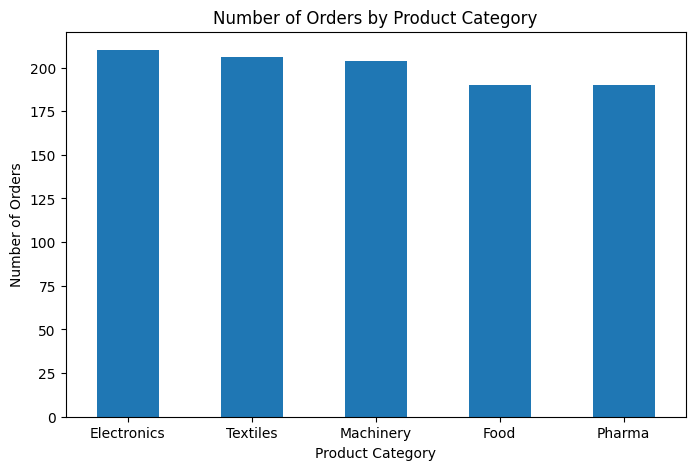

In [14]:
import matplotlib.pyplot as plt

category_counts = df["Product_Category"].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind="bar")

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

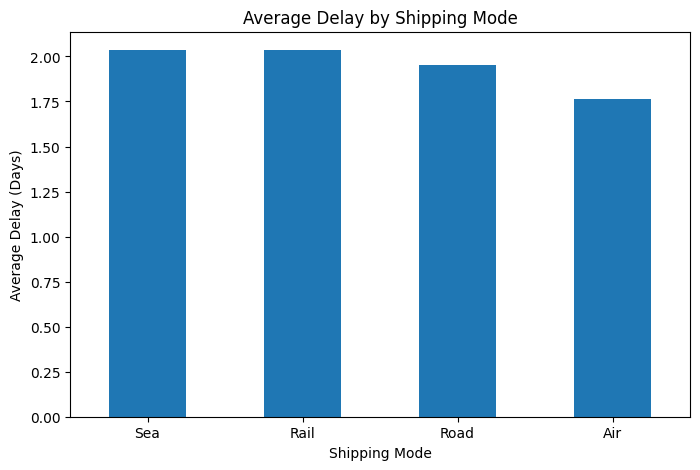

In [15]:
delay_by_shipping = df.groupby("Shipping_Mode")["Delay_Days"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
delay_by_shipping.plot(kind="bar")

plt.title("Average Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)

plt.show()

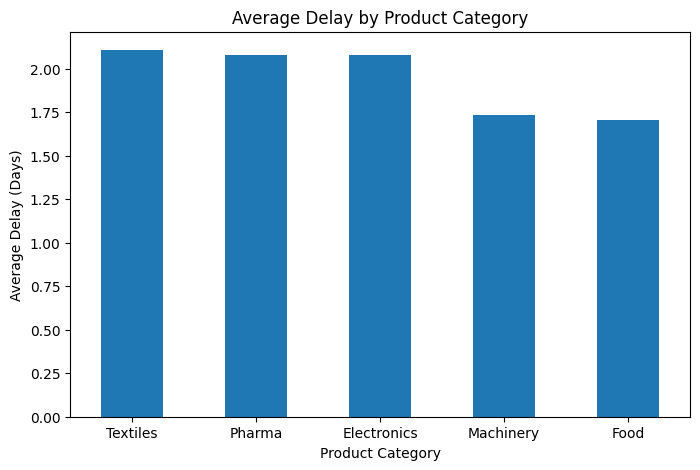

In [16]:
delay_by_category = (
    df.groupby("Product_Category")["Delay_Days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
delay_by_category.plot(kind="bar")

plt.title("Average Delay by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)

plt.show()

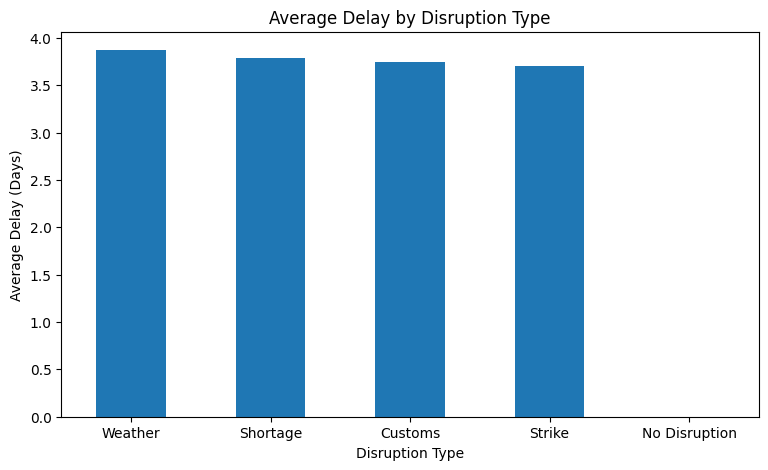

In [17]:
disruption_delay = (
    df.assign(
        Disruption_Type=df["Disruption_Type"].fillna("No Disruption")
    )
    .groupby("Disruption_Type")["Delay_Days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
disruption_delay.plot(kind="bar")

plt.title("Average Delay by Disruption Type")
plt.xlabel("Disruption Type")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)

plt.show()

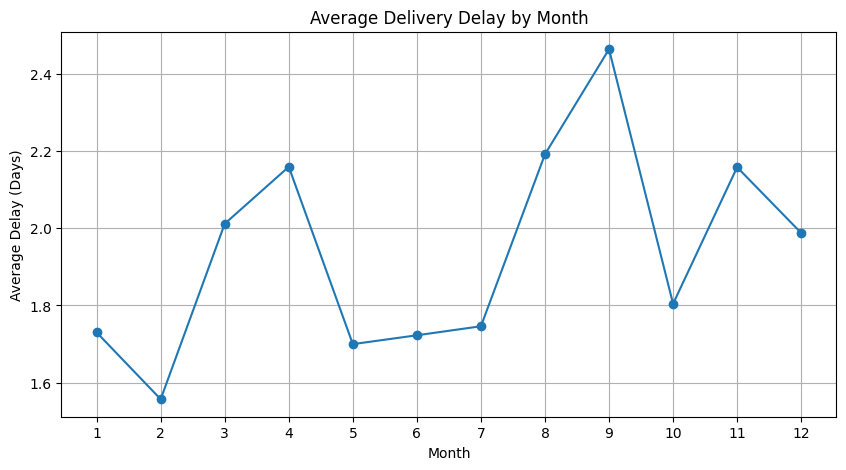

In [18]:
monthly_delay = (
    df.groupby(df["Order_Date"].dt.month)["Delay_Days"]
    .mean()
)

plt.figure(figsize=(10, 5))
monthly_delay.plot(kind="line", marker="o")

plt.title("Average Delivery Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (Days)")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

In [19]:
monthly_disruptions = (
    df.assign(
        Has_Disruption=df["Disruption_Type"].notna()
    )
    .groupby(df["Order_Date"].dt.month)["Has_Disruption"]
    .sum()
)

print("Number of disrupted orders by month:")
print(monthly_disruptions)

Number of disrupted orders by month:
Order_Date
1     45
2     28
3     48
4     46
5     50
6     39
7     35
8     54
9     49
10    41
11    40
12    39
Name: Has_Disruption, dtype: int64


In [20]:
# Create a separate dataset for machine learning
ml_df = df.copy()

# Remove columns that could reveal the outcome
columns_to_remove = [
    "Order_ID",
    "Buyer_ID",
    "Supplier_ID",
    "Organization_ID",
    "Order_Date",
    "Dispatch_Date",
    "Delivery_Date",
    "Delay_Days",
    "Disruption_Type",
    "Disruption_Severity"
]

ml_df = ml_df.drop(columns=columns_to_remove)

# Display the remaining columns
print("Columns available for machine learning:")
print(ml_df.columns.tolist())

print("\nDataset shape:")
print(ml_df.shape)

print("\nFirst 5 rows:")
display(ml_df.head())

Columns available for machine learning:
['Product_Category', 'Quantity_Ordered', 'Shipping_Mode', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Dominant_Buyer_Flag', 'Available_Historical_Records', 'Data_Sharing_Consent', 'Federated_Round', 'Parameter_Change_Magnitude', 'Communication_Cost_MB', 'Energy_Consumption_Joules', 'Supply_Risk_Flag']

Dataset shape:
(1000, 14)

First 5 rows:


,Product_Category,Quantity_Ordered,Shipping_Mode,Order_Value_USD,Historical_Disruption_Count,Supplier_Reliability_Score,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Supply_Risk_Flag
0,Textiles,469,Rail,36273.99,11,0.73,0,127,1,10,0.0225,2.27,236.06,0
1,Machinery,365,Road,34780.36,1,0.88,1,909,1,7,0.0412,3.10,257.80,0
2,Food,333,Rail,7154.54,19,0.95,0,262,1,8,0.1183,2.82,165.38,1
3,Machinery,142,Rail,15320.08,17,0.92,1,807,1,9,0.2611,3.59,377.47,0
4,Machinery,897,Road,18256.42,5,0.60,0,789,1,7,0.2775,3.42,83.10,0


In [21]:
# Create a separate dataset for machine learning
ml_df = df.copy()

# Remove columns that should not be used for prediction
columns_to_remove = [
    "Order_ID",
    "Buyer_ID",
    "Supplier_ID",
    "Organization_ID",
    "Order_Date",
    "Dispatch_Date",
    "Delivery_Date",
    "Delay_Days",
    "Disruption_Type",
    "Disruption_Severity"
]

ml_df = ml_df.drop(columns=columns_to_remove)

print("Columns available for machine learning:")
print(ml_df.columns.tolist())

print("\nDataset shape:")
print(ml_df.shape)

print("\nFirst 5 rows:")
display(ml_df.head())

Columns available for machine learning:
['Product_Category', 'Quantity_Ordered', 'Shipping_Mode', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Dominant_Buyer_Flag', 'Available_Historical_Records', 'Data_Sharing_Consent', 'Federated_Round', 'Parameter_Change_Magnitude', 'Communication_Cost_MB', 'Energy_Consumption_Joules', 'Supply_Risk_Flag']

Dataset shape:
(1000, 14)

First 5 rows:


,Product_Category,Quantity_Ordered,Shipping_Mode,Order_Value_USD,Historical_Disruption_Count,Supplier_Reliability_Score,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Supply_Risk_Flag
0,Textiles,469,Rail,36273.99,11,0.73,0,127,1,10,0.0225,2.27,236.06,0
1,Machinery,365,Road,34780.36,1,0.88,1,909,1,7,0.0412,3.10,257.80,0
2,Food,333,Rail,7154.54,19,0.95,0,262,1,8,0.1183,2.82,165.38,1
3,Machinery,142,Rail,15320.08,17,0.92,1,807,1,9,0.2611,3.59,377.47,0
4,Machinery,897,Road,18256.42,5,0.60,0,789,1,7,0.2775,3.42,83.10,0


In [22]:
# Separate input features (X) and target (y)

X = ml_df.drop("Supply_Risk_Flag", axis=1)
y = ml_df["Supply_Risk_Flag"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nTarget distribution:")
print(y.value_counts())

Features (X):
['Product_Category', 'Quantity_Ordered', 'Shipping_Mode', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Dominant_Buyer_Flag', 'Available_Historical_Records', 'Data_Sharing_Consent', 'Federated_Round', 'Parameter_Change_Magnitude', 'Communication_Cost_MB', 'Energy_Consumption_Joules']

Target (y):
Supply_Risk_Flag

Target distribution:
Supply_Risk_Flag
1    514
0    486
Name: count, dtype: int64


In [23]:
# Convert categorical columns into numerical columns

X_encoded = pd.get_dummies(
    X,
    columns=["Product_Category", "Shipping_Mode"],
    drop_first=True
)

print("Encoded features:")
print(X_encoded.columns.tolist())

print("\nNew shape:")
print(X_encoded.shape)

display(X_encoded.head())

Encoded features:
['Quantity_Ordered', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Dominant_Buyer_Flag', 'Available_Historical_Records', 'Data_Sharing_Consent', 'Federated_Round', 'Parameter_Change_Magnitude', 'Communication_Cost_MB', 'Energy_Consumption_Joules', 'Product_Category_Food', 'Product_Category_Machinery', 'Product_Category_Pharma', 'Product_Category_Textiles', 'Shipping_Mode_Rail', 'Shipping_Mode_Road', 'Shipping_Mode_Sea']

New shape:
(1000, 18)


,Quantity_Ordered,Order_Value_USD,Historical_Disruption_Count,Supplier_Reliability_Score,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Product_Category_Food,Product_Category_Machinery,Product_Category_Pharma,Product_Category_Textiles,Shipping_Mode_Rail,Shipping_Mode_Road,Shipping_Mode_Sea
0,469,36273.99,11,0.73,0,127,1,10,0.0225,2.27,236.06,False,False,False,True,True,False,False
1,365,34780.36,1,0.88,1,909,1,7,0.0412,3.10,257.80,False,True,False,False,False,True,False
2,333,7154.54,19,0.95,0,262,1,8,0.1183,2.82,165.38,True,False,False,False,True,False,False
3,142,15320.08,17,0.92,1,807,1,9,0.2611,3.59,377.47,False,True,False,False,True,False,False
4,897,18256.42,5,0.60,0,789,1,7,0.2775,3.42,83.10,False,True,False,False,False,True,False


In [24]:
# Select business-relevant features for prediction

X = ml_df[
    [
        "Product_Category",
        "Quantity_Ordered",
        "Shipping_Mode",
        "Order_Value_USD",
        "Historical_Disruption_Count",
        "Supplier_Reliability_Score"
    ]
]

print("Features selected for the model:")
print(X.columns.tolist())

print("\nShape of X:")
print(X.shape)

display(X.head())

Features selected for the model:
['Product_Category', 'Quantity_Ordered', 'Shipping_Mode', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score']

Shape of X:
(1000, 6)


,Product_Category,Quantity_Ordered,Shipping_Mode,Order_Value_USD,Historical_Disruption_Count,Supplier_Reliability_Score
0,Textiles,469,Rail,36273.99,11,0.73
1,Machinery,365,Road,34780.36,1,0.88
2,Food,333,Rail,7154.54,19,0.95
3,Machinery,142,Rail,15320.08,17,0.92
4,Machinery,897,Road,18256.42,5,0.60


In [25]:
# Convert categorical features into numerical features

X_encoded = pd.get_dummies(
    X,
    columns=["Product_Category", "Shipping_Mode"],
    drop_first=True
)

print("Encoded features:")
print(X_encoded.columns.tolist())

print("\nShape after encoding:")
print(X_encoded.shape)

display(X_encoded.head())

Encoded features:
['Quantity_Ordered', 'Order_Value_USD', 'Historical_Disruption_Count', 'Supplier_Reliability_Score', 'Product_Category_Food', 'Product_Category_Machinery', 'Product_Category_Pharma', 'Product_Category_Textiles', 'Shipping_Mode_Rail', 'Shipping_Mode_Road', 'Shipping_Mode_Sea']

Shape after encoding:
(1000, 11)


,Quantity_Ordered,Order_Value_USD,Historical_Disruption_Count,Supplier_Reliability_Score,Product_Category_Food,Product_Category_Machinery,Product_Category_Pharma,Product_Category_Textiles,Shipping_Mode_Rail,Shipping_Mode_Road,Shipping_Mode_Sea
0,469,36273.99,11,0.73,False,False,False,True,True,False,False
1,365,34780.36,1,0.88,False,True,False,False,False,True,False
2,333,7154.54,19,0.95,True,False,False,False,True,False,False
3,142,15320.08,17,0.92,False,True,False,False,True,False,False
4,897,18256.42,5,0.60,False,True,False,False,False,True,False


In [26]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data:
X_train: (800, 11)
y_train: (800,)

Testing data:
X_test: (200, 11)
y_test: (200,)

Training target distribution:
Supply_Risk_Flag
1    411
0    389
Name: count, dtype: int64

Testing target distribution:
Supply_Risk_Flag
1    103
0     97
Name: count, dtype: int64


In [27]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [29]:
# Make predictions on the test data

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1]


In [30]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 49.50%


In [31]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 50.85%
Recall: 58.25%


Confusion Matrix:
[[39 58]
 [43 60]]


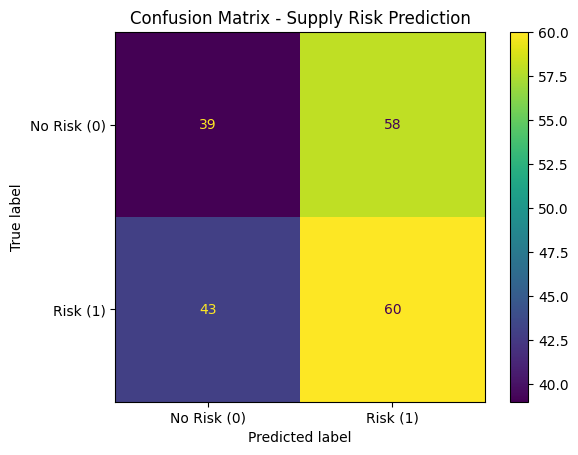

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Risk (0)", "Risk (1)"]
)

disp.plot()
plt.title("Confusion Matrix - Supply Risk Prediction")
plt.show()

In [33]:
# Get predicted probability of supply risk

risk_probability = model.predict_proba(X_test_scaled)[:, 1]

print("First 20 risk probabilities:")
print(risk_probability[:20])

print("\nMinimum probability:", risk_probability.min())
print("Maximum probability:", risk_probability.max())

First 20 risk probabilities:
[0.52168876 0.55402394 0.54094815 0.53003688 0.4446227  0.54950824
 0.556249   0.45482275 0.52079061 0.59116991 0.5330027  0.53466247
 0.52138755 0.51946631 0.48008531 0.53333627 0.5237694  0.49721779
 0.47755922 0.54171346]

Minimum probability: 0.42457669037093404
Maximum probability: 0.6142302185594793


In [34]:
# Convert predicted probabilities into risk levels

def assign_risk_level(probability):
    if probability < 0.45:
        return "Low Risk"
    elif probability <= 0.55:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [assign_risk_level(p) for p in risk_probability]

print("First 20 risk levels:")
print(risk_levels[:20])

print("\nRisk level distribution:")
print(pd.Series(risk_levels).value_counts())

First 20 risk levels:
['Medium Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk']

Risk level distribution:
Medium Risk    151
High Risk       40
Low Risk         9
Name: count, dtype: int64


In [35]:
# Create a final prediction results table

results = pd.DataFrame({
    "Actual_Risk": y_test.values,
    "Predicted_Risk": y_pred,
    "Risk_Probability": risk_probability,
    "Risk_Level": risk_levels
})

# Show the first 20 predictions
display(results.head(20))

,Actual_Risk,Predicted_Risk,Risk_Probability,Risk_Level
0,1,1,0.521689,Medium Risk
1,0,1,0.554024,High Risk
2,1,1,0.540948,Medium Risk
3,0,1,0.530037,Medium Risk
4,1,0,0.444623,Low Risk
5,1,1,0.549508,Medium Risk
6,1,1,0.556249,High Risk
7,0,0,0.454823,Medium Risk
8,0,1,0.520791,Medium Risk
9,0,1,0.591170,High Risk


Dataset: 1,000 orders
Training set: 800
Testing set: 200
Accuracy: 49.50%
Precision: 50.85%
Recall: 58.25%
Low Risk: 9
Medium Risk: 151
High Risk: 40



# Key Findings

1. The dataset contains 1,000 supply-chain orders across five product categories and four shipping modes.

2. Delivery delays varied across shipping modes, with Sea and Rail showing higher average delays than some other modes.

3. Delivery delays also differed across product categories.

4. Orders associated with recorded disruptions showed substantially higher delays than orders without recorded disruptions.

5. The September period showed the highest average delivery delay in the dataset.

6. The leakage-aware Logistic Regression model achieved 49.50% accuracy on unseen test data, showing that the selected pre-event features had limited predictive power for the Supply Risk Flag.Sea and Rail showed higher average delays than Air and Road.

# Limitations

- The dataset contains only 1,000 orders.
- The available pre-event business features had limited predictive power for the Supply Risk Flag.
- Disruption-related variables were excluded from prediction because they directly corresponded with the target and could cause target leakage.
- The probability thresholds used for Low, Medium, and High Risk are project-defined thresholds and have not been validated for real-world operations.
- Additional operational and historical features may be required to build a more reliable predictive model.

# Conclusion

This project analyzed 1,000 supply-chain orders to identify patterns in delivery delays and supply risk.

Exploratory analysis showed differences in average delivery delays across shipping modes, product categories, disruption types, and months. A leakage-aware Logistic Regression model was developed using six business-relevant pre-event features: product category, quantity ordered, shipping mode, order value, historical disruption count, and supplier reliability score.

The model was evaluated on 200 unseen test orders and achieved 49.50% accuracy, 50.85% precision, and 58.25% recall.

The results indicate that the selected pre-event features alone were not sufficient to reliably predict the dataset's Supply Risk Flag. The model therefore provides a baseline for future improvement rather than a production-ready prediction system.

Future work could include additional historical supplier information, transportation characteristics, seasonal factors, and other operational variables to improve predictive performance.